In [2]:
import numpy as np
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import seaborn as sns

# The goal of this notebook is to find a way to compute the velocity attenuation ratio of a PIV dataset. Several strategies will be attempted
# and compared. Specifically, I want the ration of flow speed local to polyps over the free stream flow speed far from the coral. I am also
# not sure whether I am supposed to use the magnitude of the velocity (speed) or just the x-component (u). As such, there will be variations
# for that as well

# I need to be able to both characterize around the polyps (still unclear whether one or all) and then across the whole image. I think
# starting with the latter will be a bit easier.

#Some possible distinctions:
#1. Single frame vs composite over many frames
#2. Single polyp vs many polyps
#3. U component vs speed

In [3]:
def break_down_data(filename):
    '''
    Reads the csv file and derives some useful numbers. Used to save space when a function takes a filename as an input.

    Parameters:
    String filename: path to the file you would like to analyze

    Returns, in order:
    DataFrame data = the Pandas DataFrame with all data
    String xcol, ycol, ucol, vcol = the names of the columns with the x coordinate, y coordinate, u-component of velocity, and v-component of 
    velocity, respectively. Allows generalizability with calibrated and noncalibrated data.
    int col_len = the number of data points
    vec_dist = the distance between each vector data point
    int xmin, xmax = maximum and minimum x values in the ORIGINAL data
    Numpy Array xrange = A numpy arange array of all x data. Does not correspond to image coordinates or the max/min
    int ymin, ymax = maximum and minimum y values in the ORIGINAL data
    Numpy Array yrange = A numpy arange array of all y data. Does not correspond to image coordinates or the max/min
    Numpy 2D Array xy = An array that creates a grid with exactly as many entries as there will be data points
    '''

    data = pd.read_csv(filename)

    #Get column names for x, y, and u. This makes it generalizable between calibrated and uncalibrated data
    xcol = data.columns[0]
    ycol = data.columns[1]
    ucol = data.columns[2]
    vcol = data.columns[3]
    #define the amount of data points (assuming same number of data in each col)
    col_len = len(data[xcol])

    #finds distance between vectors (will be useful later)
    for i in np.arange(col_len):
        vec_dist = data[xcol][i]-data[xcol][0]
        if vec_dist != 0:
            break

    #Some useful size variables
    xmin = data[xcol].min()
    xmax = data[xcol].max()
    xrange = np.unique(data[xcol])
    ymin = data[ycol].min()
    ymax = data[ycol].max()
    yrange = np.unique(data[ycol])
    #Initialize an array 
    xy = np.empty((len(yrange), len(xrange)))

    return data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, xy

In [122]:
def dataframe_val_init(data):
    '''
    I'm lazy. This makes me not need one billion inputs for each function. Used to save space when a function takes a DataFrame as an input.

    Parameters:
    DataFrame data: dataframe you want vals from

    Returns, in order:
    String xcol, ycol, ucol, vcol = the names of the columns with the x coordinate, y coordinate, u-component of velocity, and v-component of 
    velocity, respectively. Allows generalizability with calibrated and noncalibrated data.
    int col_len = the number of data points
    vec_dist = the distance between each vector data point
    int xmin, xmax = maximum and minimum x values in the ORIGINAL data
    int ymin, ymax = maximum and minimum y values in the ORIGINAL data
    '''

    #Get column names for x, y, and u. This makes it generalizable between calibrated and uncalibrated data
    xcol = data.columns[0]
    ycol = data.columns[1]
    ucol = data.columns[2]
    vcol = data.columns[3]
    #define the amount of data points (assuming same number of data in each col)
    col_len = len(data[xcol])

    #finds distance between vectors (will be useful later)
    for i in np.arange(col_len):
        vec_dist = data[xcol][i]-data[xcol][0]
        if vec_dist != 0:
            break

    #Some useful size variables
    xmin = data[xcol].min()
    xmax = data[xcol].max()
    xrange = np.unique(data[xcol])
    ymin = data[ycol].min()
    ymax = data[ycol].max()
    yrange = np.unique(data[ycol])

    return xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, ymin, ymax

In [123]:
def mean_mag_velocity_rect(data, left, right, bott, top):
    '''
    Returns the mean magnitude of the velocity over a specified RECTANGULAR area.

    Parameters:
    DataFrame data = your original dataset with coordinates
    float left, right, bott, top = the coordinates of the corners. left = min x, right = max x, bott = min y, top = max x
    '''
    xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, ymin, ymax = dataframe_val_init(data)
    counter = 0
    cumsum = 0
    
    for i in np.arange(col_len):
        if (data[xcol][i]>(right) and data[ycol][i]>(top)):
                break #to save unneccesary computation over the rest of the frame
        if (data[xcol][i]>=left and data[xcol][i]<=right and data[ycol][i]<=top and data[ycol][i]>=bott and not np.isnan(data[ucol][i])):
            counter+=1
            temp = (data[ucol][i])**2+(data[vcol][i])**2 # x^2+y^2
            cumsum+= math.sqrt(temp) #(x^2+y^2)^(1/2)
    mean_mag = cumsum/counter
    return mean_mag

In [6]:
def draw_heatmap(array, title, diverging = True, normalized = False):
    '''
    Graphs a given 2D array with a heatmap centered at 0, using a dark, diverging colormap that allows masks and NaNs to be seen.
    X and Y labels are turned off and assumed to be relative.

    Parameters:
    2D Array or Arraylike array: a NumPy array or Pandas DataFrame or whatever with the data you want plotted
    String title: Describes what's being plotted
    ''' 
    
    #Graphs the data using a seaborn heatmap
    if diverging:
        heatmap = sns.heatmap(array, center = 0, cmap = "berlin", xticklabels = False, yticklabels = False)
    elif normalized:
        heatmap = sns.heatmap(array, vmin = 0, vmax = 1, cmap = "viridis", xticklabels = False, yticklabels = False)
    #heatmap.xaxis.tick_top()
    plt.xlabel("x (relative)")
    plt.ylabel("y (relative)")
    plt.title(title)
    plt.tight_layout(pad=2.0)

In [7]:
def testMap_u(filename):
    '''
    Returns a heatmap of horizontal speed magnitude, u, and masked out regions are clearly distinguishable. Used to test making heatmaps using
    the Seaborn heatmap() function.

    Parameters:
    str filename: name of the file
    '''

    data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, xy = break_down_data(filename)
    
    #pass through the data to assign values to the array
    for i in np.arange(col_len):
        #x and y position (correcting for displacement from the origin and vector count)
        xpos = int((data[xcol][i]-xmin)/vec_dist)
        ypos = int((data[ycol][i]-ymin)/vec_dist)
        #u component at that position. THIS IS THE PLACE TO EDIT FOR DIFFERENT VALUES!!
        u_xy = data[ucol][i]
        xy[ypos][xpos] = u_xy

    #I know this is all convoluted I just don't know how to do it better

    draw_heatmap(xy, "u-component of velocity")

In [24]:
def velocity_attenuation_heatmap(filename, left, right, bott, top):
    '''
    Returns two heatmaps of velocity attenuation compared to a defined free-stream area for an individual frame.
    One will compare strictly the u-component. One will compare the magnitude of the velocity.

    Also draws a rectangle of the defined free stream area over the plot. If you are working with the very boundary of the image, add one pixel to 
    make sure the box shows up properly (i.e. image ends on pixel 800, put right as 801 for the right bound) 

    Parameters:
    String filename: path of file for analysis

    The following parameters are meant to give a rectangle of area considered to have "free stream" behavior, far away from the coral sample.
    These values are INCLUSIVE
    int left: Left bound (lowest x-val)
    int top: Top bound (highest y-val)
    int right: Right bound (highest x-val)
    int bott: Bottom bound (lowest y-val)
    These assume x increasing to the right and y increasing toward the bottom

    Credit to Dr. Alison Weber for help debugging the box around the free stream
    '''

    #Unloads data
    data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, pointarray_mag = break_down_data(filename)
    pointarray_u = pointarray_mag.copy()
    
    #Average u and mag over the rectangle using a for loop to get the free stream velocity

    #u component
    counter = 0
    cumsum = 0
    for i in np.arange(col_len):
        if (data[xcol][i]>=left and data[xcol][i]<=right and data[ycol][i]<=top and data[ycol][i]>=bott):
            counter+=1
            cumsum+=data[ucol][i]
    mean_u = cumsum/counter

    #velocity magnitude
    mean_mag = mean_mag_velocity_rect(data, left, right, bott, top)
    
    #For the whole data set, find the velocity attenuation as the velocity at that point over the free stream velocity
    #Add the results to the original DataFrame

    #u component
    u_attenuation = np.zeros(col_len)
    for i in np.arange(col_len):
        u_attenuation[i] = data[ucol][i]/mean_u
        
    #pass through the data to assign values to the array
    i=0
    for x in np.arange(len(xrange)):
        for y in np.arange(len(yrange)):
            pointarray_u[y][x] = u_attenuation[i]
            i+=1

    #vel magnitude
    mag_attenuation = np.zeros(col_len)
    velmag = np.zeros(col_len)
    for i in np.arange(col_len):
        temp = (data[ucol][i])**2+(data[vcol][i])**2 # x^2+y^2
        temp = math.sqrt(temp) #(x^2+y^2)^(1/2)
        velmag[i] = temp
        mag_attenuation[i] = temp/mean_mag

    #pass through the data to assign values to the array
    i=0
    for x in np.arange(len(xrange)):
        for y in np.arange(len(yrange)):
            pointarray_mag[y][x] = mag_attenuation[i]
            i+=1
    
    #Graph each using the draw_heatmap() function
    #Also box off free stream area using rect = mpatches.Rectangle((left, bottom), width, height, fill=False, edgecolor="color", linewidth=width)

    #First, create the subplots
    fig, axes = plt.subplots(1, 2, figsize=(11,5), sharey=True)
    #define the coordinates of the box in the modified grid
    fl = np.floor((left-xmin)/vec_dist)
    fr = np.ceil((right-xmin)/vec_dist)
    ft = np.ceil((top-ymin)/vec_dist)
    fb = np.floor((bott-ymin)/vec_dist)
    
    fswidth = fr-fl
    fsheight = ft-fb
    
    #Plot the top graph
    plt.sca(axes[0])
    draw_heatmap(pointarray_u, "Velocity Attenuation Ratio for U Component", normalized = True, diverging = False)
    rect = mpatches.Rectangle((fl, fb), fswidth, fsheight, fill=False, edgecolor="red", linewidth=2)
    axes[0].add_patch(rect)
    rect.set_zorder(10000)

    plt.sca(axes[1])
    draw_heatmap(pointarray_mag, "Velocity Attenuation Ratio for Total Velocity Magnitude", normalized = True, diverging = False)
    rect2 = mpatches.Rectangle((fl, fb), fswidth, fsheight, fill=False, edgecolor="red", linewidth=2)
    axes[1].add_patch(rect2)
    rect2.set_zorder(10000)

    plt.show()

In [142]:
def small_area_attenuation_rect(filename, pl, pr, pb, pt, fl, fr, fb, ft):
    '''
    Returns the average velocity attenuation of some small area (such as the region around a polyp or other structure) compared with some defined
    free stream region. This applies to ONE frame.

    Parameters:
    String filename: path of file for analysis

    float pl = literally "polyp left", left coordinate of the region of interest
    float pr = literally "polyp right", right coordinate of the region of interest
    float pb = literally "polyp bottom", bottom (lowest y value) coordinate of the region of interest
    float pt = literally "polyp top", top (highest y value) coordinate of the region of interest

    float fl = literally "free stream left", left coordinate of the free stream region
    float fr = literally "free stream right", right coordinate of the free stream region
    float fb = literally "free stream bottom", bottom (lowest y value) coordinate of the free stream region
    float ft = literally "free stream top", top (highest y value) coordinate of the free stream region

    Returns:
    float attenuation = the velocity attenuation ratio between the mean magnitude of velocity of the ROI and the mean magnitude of velocity of 
    the free stream region
    
    '''
    #Unpack the filename
    data = pd.read_csv(filename)
    #Recycle code to get free stream velocity
    mean_mag_FS = mean_mag_velocity_rect(data, fl, fr, fb, ft)
    #Recycle again to get ROI velocity
    mean_mag_ROI = mean_mag_velocity_rect(data, pl, pr, pb, pt)
    attenuation = mean_mag_ROI/mean_mag_FS
    return attenuation

In [153]:
def timeavg_small_area_attenuation_rect(filename, start_frame, end_frame, pl, pr, pb, pt, fl, fr, fb, ft, digits = 4):
    '''
    Returns the average velocity attenuation of some small area (such as the region around a polyp or other structure) compared with some defined
    free stream region. This applies to ONE frame.

    Parameters:
    String filename: path of file for analysis UNTIL THE STRING OF NUMBERS THAT DENOTES FRAME NUMBER

    int start_frame = the first frame you want analyzed
    int end_frame = the last frame you want analyzed (i.e. inclusive!)

    float pl = literally "polyp left", left coordinate of the region of interest
    float pr = literally "polyp right", right coordinate of the region of interest
    float pb = literally "polyp bottom", bottom (lowest y value) coordinate of the region of interest
    float pt = literally "polyp top", top (highest y value) coordinate of the region of interest

    float fl = literally "free stream left", left coordinate of the free stream region
    float fr = literally "free stream right", right coordinate of the free stream region
    float fb = literally "free stream bottom", bottom (lowest y value) coordinate of the free stream region
    float ft = literally "free stream top", top (highest y value) coordinate of the free stream region

    (optional) int digits: Default = 4. The string of numbers at the end of your file names should not be included in filename. How many 'digits' are there 
    of the string of numbers at the end? i.e, for file data_0001, digits=4. For file data_001, digits=3.

    Returns:
    float attenuation = the velocity attenuation ratio between the mean magnitude of velocity of the ROI and the mean magnitude of velocity of 
    the free stream region
    
    '''
    #Define variables
    framect = end_frame - start_frame + 1 #because inclusive
    cum_attenuation = 0

    #for each frame, 1) get the filename, 2) unpack the data, 3) find attenuation
    for i in np.arange(framect):
        numstring = str(start_frame+i)
        while len(numstring)<digits:
            numstring = "0"+numstring
        fullfile = filename + numstring + ".txt"
        data = pd.read_csv(fullfile)

        #get attenuation per frame
        cum_attenuation += small_area_attenuation_rect(fullfile, pl, pr, pb, pt, fl, fr, fb, ft)

    avg_att = cum_attenuation/framect
    return avg_att

In [154]:
def timeavg_small_area_attenuation_rect_backup(filename, start_frame, end_frame, pl, pr, pb, pt, fl, fr, fb, ft, digits = 4):
    '''
    Returns the average velocity attenuation of some small area (such as the region around a polyp or other structure) compared with some defined
    free stream region. This applies to ONE frame.

    Parameters:
    String filename: path of file for analysis UNTIL THE STRING OF NUMBERS THAT DENOTES FRAME NUMBER

    int start_frame = the first frame you want analyzed
    int end_frame = the last frame you want analyzed (i.e. inclusive!)

    float pl = literally "polyp left", left coordinate of the region of interest
    float pr = literally "polyp right", right coordinate of the region of interest
    float pb = literally "polyp bottom", bottom (lowest y value) coordinate of the region of interest
    float pt = literally "polyp top", top (highest y value) coordinate of the region of interest

    float fl = literally "free stream left", left coordinate of the free stream region
    float fr = literally "free stream right", right coordinate of the free stream region
    float fb = literally "free stream bottom", bottom (lowest y value) coordinate of the free stream region
    float ft = literally "free stream top", top (highest y value) coordinate of the free stream region

    (optional) int digits: Default = 4. The string of numbers at the end of your file names should not be included in filename. How many 'digits' are there 
    of the string of numbers at the end? i.e, for file data_0001, digits=4. For file data_001, digits=3.

    Returns:
    float attenuation = the velocity attenuation ratio between the mean magnitude of velocity of the ROI and the mean magnitude of velocity of 
    the free stream region
    
    '''
    #Define variables
    framect = end_frame - start_frame + 1 #because inclusive
    cum_attenuation = 0

    #for each frame, 1) get the filename, 2) unpack the data, 3) find attenuation
    for i in np.arange(framect):
        numstring = str(start_frame+i)
        while len(numstring)<digits:
            numstring = "0"+numstring
        fullfile = filename + numstring + ".txt"
        data = pd.read_csv(fullfile)
        #Recycle code to get free stream velocity
        mean_mag_FS = mean_mag_velocity_rect(data, fl, fr, fb, ft)
        #Recycle again to get ROI velocity
        mean_mag_ROI = mean_mag_velocity_rect(data, pl, pr, pb, pt)
        cum_attenuation += (mean_mag_ROI/mean_mag_FS)

    avg_att = cum_attenuation/framect
    return avg_att

In [97]:
def small_area_attenuation_rad(filename, px, py, fl, fr, fb, ft, radius):
    '''
    Returns the average velocity attenuation of some small area (such as the region around a polyp or other structure) compared with some defined
    free stream region. This applies to ONE frame.

    Parameters:
    String filename: path of file for analysis

    float px = literally "polyp x", x coordinate of the center of the region of interest
    float py = literally "polyp y", y coordinate of the center of the region of interest

    float fl = literally "free stream left", left coordinate of the free stream region
    float fr = literally "free stream right", right coordinate of the free stream region
    float fb = literally "free stream bottom", bottom (lowest y value) coordinate of the free stream region
    float ft = literally "free stream top", top (highest y value) coordinate of the free stream region

    float radius: How far out from the center of the region of interest are we going? Make sure not to make this too small (such that no vectors are caught)
    or too large (such that free stream behavior dominates)

    Returns:
    float attenuation = the velocity attenuation ratio between the mean magnitude of velocity of the ROI and the mean magnitude of velocity of 
    the free stream region
    
    '''

    #Unpack the filename
    data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, unneccesary_array = break_down_data(filename)
    #Recycle code to get free stream velocity
    mean_mag_FS = mean_mag_velocity_rect(data, fl, fr, fb, ft)

    counter = 0
    cumsum = 0
    for i in np.arange(col_len):
        distance = (data[xcol][i]-px)**2+(data[ycol][i]-py)**2
        distance = math.sqrt(distance)
        if (distance<=radius and not np.isnan(data[ucol][i])):
            if (data[xcol][i]>(px+radius) and data[ycol][i]>(py+radius)):
                break #to save unneccesary computation over the rest of the frame
            counter+=1
            temp = (data[ucol][i])**2+(data[vcol][i])**2 # x^2+y^2
            cumsum+= math.sqrt(temp) #(x^2+y^2)^(1/2)
    mean_mag_ROI = cumsum/counter

    #divide and return
    attenuation = mean_mag_ROI/mean_mag_FS
    return attenuation

In [147]:
def timeavg_small_area_attenuation_rad(filename, start_frame, end_frame, px, py, fl, fr, fb, ft, radius, digits = 4):
    '''
    Returns the average velocity attenuation of some small area (such as the region around a polyp or other structure) compared with some defined
    free stream region. This applies to ONE frame.

    Parameters:
    String filename: path of file for analysis UNTIL THE STRING OF NUMBERS THAT DENOTES FRAME NUMBER

    int start_frame = the first frame you want analyzed
    int end_frame = the last frame you want analyzed (i.e. inclusive!)

    float px = literally "polyp x", x coordinate of the center of the region of interest
    float py = literally "polyp y", y coordinate of the center of the region of interest

    float fl = literally "free stream left", left coordinate of the free stream region
    float fr = literally "free stream right", right coordinate of the free stream region
    float fb = literally "free stream bottom", bottom (lowest y value) coordinate of the free stream region
    float ft = literally "free stream top", top (highest y value) coordinate of the free stream region

    float radius: How far out from the center of the region of interest are we going? Make sure not to make this too small (such that no vectors are caught)
    or too large (such that free stream behavior dominates)

    Returns:
    float attenuation = the velocity attenuation ratio between the mean magnitude of velocity of the ROI and the mean magnitude of velocity of 
    the free stream region
    
    '''

    #Define variables
    framect = end_frame - start_frame + 1 #because inclusive
    cum_attenuation = 0
    attenuation = np.zeros(framect)

    #for each frame, 1) get the filename, 2) unpack the data, 3) find the free stream velocity, 4) find the ROI velocity, 5) find attenuation
    for j in np.arange(framect):
        
        #get full file name
        numstring = str(start_frame+j)
        while len(numstring)<digits:
            numstring = "0"+numstring
        fullfile = filename + numstring + ".txt"
        data = pd.read_csv(fullfile)
        
        #get attenuation per frame
        cum_attenuation += small_area_attenuation_rad(fullfile, px, py, fl, fr, fb, ft, radius)

    #Average over time and return
    avg_att = cum_attenuation/framect
    return avg_att

In [108]:
#Testing zone: unload files and variables

#testfile = "C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation Python Code/filtered_t5_2pass_small/filtered_t5_2pass_small_0090.txt"
#testfile = "C:/Users/oksan/AppData/Roaming/.anaconda/navigator/scripts/SSR_2026/Input/catiedata_score3_frame87_unfiltered_75pct-speed.txt"
#testfile = "C:/Users/oksan/AppData/Roaming/.anaconda/navigator/scripts/SSR_2026/Input/mydata6.25_score1_frame1_unfiltered_100pct-speed.txt"
#testfile = "C:/Users/oksan/AppData/Roaming/.anaconda/navigator/scripts/SSR_2026/Input/mydata6.25_score2_frame249_unfiltered_100pct-speed.txt"
testfile = "Input/polyp-att-test_catiedata_score3_frame33_unfiltered_75pct-speed.txt"
rootfile = "Input/catiedata_score3_75pctspeed_unfiltered/catiethesisdata_score3_75pc_unfiltered_"
data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange, ymin, ymax, yrange, pointarray_mag = break_down_data(testfile)
print(xrange, yrange)

[ 261  281  301  321  341  361  381  401  421  441  461  481  501  521
  541  561  581  601  621  641  661  681  701  721  741  761  781  801
  821  841  861  881  901  921  941  961  981 1001 1021 1041 1061 1081
 1101 1121 1141 1161 1181 1201 1221 1241 1261] [  23   43   63   83  103  123  143  163  183  203  223  243  263  283
  303  323  343  363  383  403  423  443  463  483  503  523  543  563
  583  603  623  643  663  683  703  723  743  763  783  803  823  843
  863  883  903  923  943  963  983 1003]


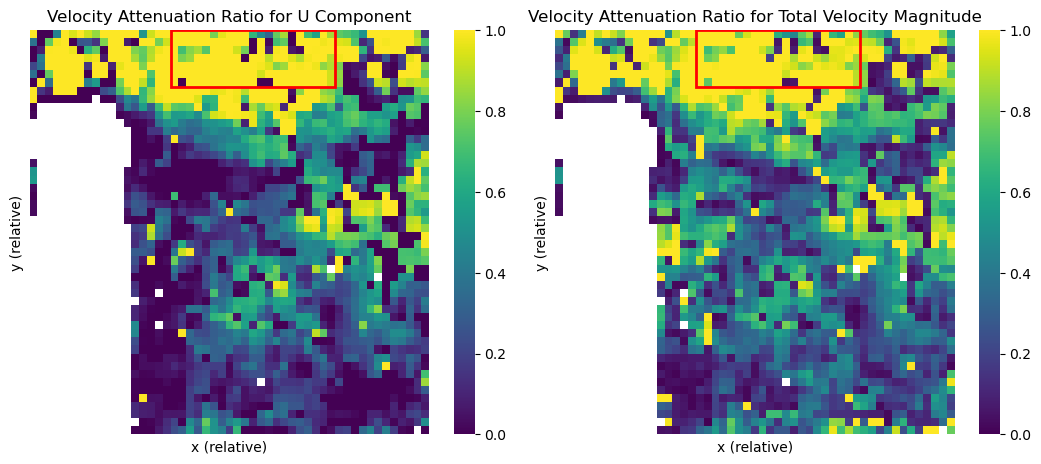

0.5324741048880232 0.6237981408243242


In [129]:
#Testing zone: try functions
velocity_attenuation_heatmap(testfile, 621, 1041, 23, 163)
radius = 40
radatt_onefr = small_area_attenuation_rad(testfile, 441, 167, 621, 1041, 23, 163, radius)
radatt_tavg = timeavg_small_area_attenuation_rad(rootfile, 100, 200, 441, 167, 621, 1041, 23, 163, radius)
att_onefr = small_area_attenuation_rect(testfile, 261, 541, 163, 263, 621, 1041, 23, 163)
att_tavg = timeavg_small_area_attenuation_rect(rootfile, 100, 200, 261, 541, 163, 263, 621, 1041, 23, 163)
print(radatt_onefr, radatt_tavg)
#print(att_onefr, att_tavg)